### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cuda device is available


#### 1. Загрузка данных.

In [3]:
# do not change the code in the block below
# __________start of block__________
!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

--2026-03-15 12:49:55--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.005s  

2026-03-15 12:49:55 (47.9 MB/s) - ‘onegin.txt’ saved [262521/262521]



#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [4]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [5]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________

Пример батча:

In [6]:
next(generate_chunk())

array([[83, 55, 45, ...,  1, 47,  1],
       [83, 51, 53, ...,  1, 48, 59],
       [83, 49,  1, ..., 62, 56, 64],
       ...,
       [83,  1, 57, ..., 73,  1, 49],
       [83, 59, 56, ..., 14,  1, 55],
       [83, 59, 57, ..., 55, 56, 50]])

Далее вам предстоит написать код для обучения модели и генерации текста.

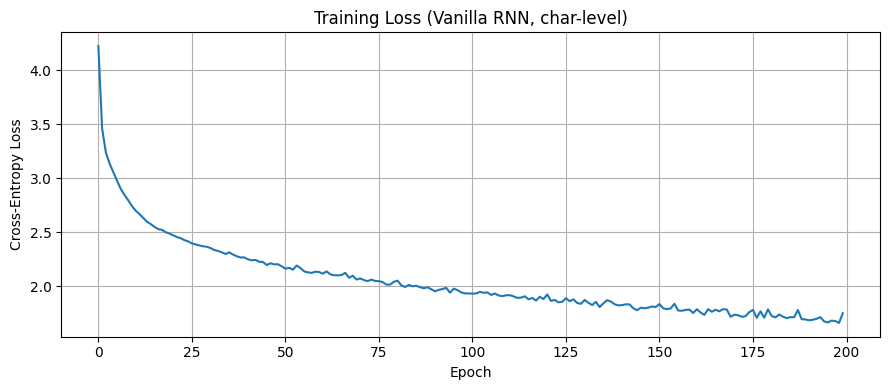

Epoch 200/200 | Loss: 1.7491


In [7]:
# your beautiful experiments here
# ============================================================
# 1. Определение Vanilla RNN
# ============================================================
class VanillaRNN(nn.Module):
    def __init__(self, num_tokens, emb_size, hidden_size):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding  = nn.Embedding(num_tokens, emb_size)
        self.rnn        = nn.RNN(emb_size, hidden_size, batch_first=True)
        self.linear     = nn.Linear(hidden_size, num_tokens)

    def forward(self, x, h=None):
        emb    = self.embedding(x)       # (batch, seq, emb_size)
        out, h = self.rnn(emb, h)        # out: (batch, seq, hidden_size)
        logits = self.linear(out)        # (batch, seq, num_tokens)
        return logits, h


# ============================================================
# 2. Гиперпараметры и инициализация
# ============================================================
emb_size         = 64
hidden_size      = 256
n_epochs         = 200
chunks_per_epoch = 5
learning_rate    = 1e-3

model     = VanillaRNN(num_tokens, emb_size, hidden_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# ============================================================
# 3. Цикл обучения
# ============================================================
losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for _ in range(chunks_per_epoch):
        chunk = next(generate_chunk())                          # (batch_size, seq_length+1)
        chunk = torch.tensor(chunk, dtype=torch.long).to(device)

        x = chunk[:, :-1]   # вход: всё кроме последнего
        y = chunk[:, 1:]    # цель: всё кроме первого (<sos>)

        optimizer.zero_grad()
        logits, _ = model(x)                                    # (batch, seq_len, num_tokens)
        loss = criterion(logits.reshape(-1, num_tokens), y.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)       # gradient clipping
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / chunks_per_epoch
    losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        clear_output(True)
        plt.figure(figsize=(9, 4))
        plt.plot(losses)
        plt.xlabel('Epoch')
        plt.ylabel('Cross-Entropy Loss')
        plt.title('Training Loss (Vanilla RNN, char-level)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        print(f'Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}')


В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [8]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling. higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else:
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    # ---- YOUR CODE HERE ----
    char_rnn.eval()
    with torch.no_grad():
        # Прогоняем seed через RNN → получаем начальное скрытое состояние
        logits, h = char_rnn(x_sequence)

        # Сколько ещё токенов нужно сгенерировать
        seed_len   = len(seed_phrase) if seed_phrase else 0
        n_generate = max_length - seed_len

        for _ in range(n_generate):
            # Берём логиты последнего шага, делим на температуру
            last_logits = logits[:, -1, :] / temperature          # (1, num_tokens)
            probs       = F.softmax(last_logits, dim=-1)
            next_ix     = torch.multinomial(probs, num_samples=1)  # (1, 1)

            # Добавляем новый токен в последовательность
            x_sequence = torch.cat([x_sequence, next_ix], dim=1)

            # Один шаг RNN с обновлённым h
            logits, h = char_rnn(next_ix, h)
    # ---- END OF YOUR CODE ----

    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])


Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [16]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правила доле
сердится тобнул он. при лораки,
и отешта болезы моей;
просила готовить видельным.



xviii

онгеча, шумный увад бедные лет
и отпадут;
и вас постольном окнове)
отворишь, как перою нео.
прикойный каб же сперться, утоплена
храк издавно, мне послежной,
кто важно нежноманьем
в соседшись… мабутели
и жердной листом игру,
когда на слуга столубу страстной,
мученькою друзья альбовну,
и навси то ж, милая годо,
где умолчен и нрохом,
и силь ж нет иходит и привность
рывал 


### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [10]:
seed_phrase = ' мой дядя самых честных правил'

In [11]:
generated_phrases = [
    generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=0.8
    ).replace('<sos>', '')
    for _ in range(10)
]


# For example:

# generated_phrases = [
#     generate_sample(
#         model,
#         ' мой дядя самых честных правил',
#         max_length=500,
#         temperature=1.
#     ).replace('<sos>', '')
#     for _ in range(10)
# ]

In [12]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'


submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!